In [ ]:
import pandas as pd
# Carico i dati da un file csv con il nome "Tabella_Pv.csv" in C:\Users\vinsc\Documents\Progetti
Tabella_Pv = pd.read_csv(r"C:\Users\vinsc\Documents\Progetti\Tabella_Pv.csv", index_col=0)
# Carico i dati da un file csv con il nome "Tabella_Load.csv" in C:\Users\vinsc\Documents\Progetti
Tabella_Load= pd.read_csv(r"C:\Users\vinsc\Documents\Progetti\Tabella_Load.csv", index_col=0)

In [ ]:
#Cambio nome alla colonna Time in DateTime
Tabella_Load = Tabella_Load.rename(columns={"Time": "DateTime"})
print(Tabella_Load.head())

              DateTime    House1    House2    House3    House4    House5  \
0  2023-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
1  2023-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2  2023-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
3  2023-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
4  2023-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   

    House11  Total_Load  
0  0.209238    1.769925  
1  0.176473    1.904744  
2  0.141122    1.941006  
3  0.121543    1.845225  
4  0.135342    1.829802  


In [ ]:
print(Tabella_Pv.head())

              DateTime  Day_of_Year Day_Name Month_Name Season  Year        Pv
0  2025-11-30 21:00:00          334   Sunday   November   Fall  2025  0.872632
1  2025-11-30 18:00:00          334   Sunday   November   Fall  2025  0.631878
2  2025-11-30 16:00:00          334   Sunday   November   Fall  2025  0.631878
3  2025-11-30 23:00:00          334   Sunday   November   Fall  2025  1.011269
4  2025-11-30 06:00:00          334   Sunday   November   Fall  2025  0.724908


In [ ]:
#Unisco le due tabelle in una sola tabella chiamata Tabella_Batteria, unendo le righe in base alla colonna DateTime
Tabella_Batteria = pd.merge(Tabella_Load,Tabella_Pv, on="DateTime", how="left")

#Stampo le prime 5 righe della tabella Tabella_Batteria
print(Tabella_Batteria.head())

              DateTime    House1    House2    House3    House4    House5  \
0  2023-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
1  2023-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2  2023-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
3  2023-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
4  2023-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   

    House11  Total_Load  Day_of_Year Day_Name Month_Name Season    Year  \
0  0.209238    1.769925        261.0   Monday  September   Fall  2023.0   
1  0.176473    1.904744        261.0   Monday  September   Fall  2023.0   
2  0.141122    1.941006        261.0   Monday  September   Fall  2023.0   
3  0.121543    1.845225        261.0   Monday  September   Fall  2023.0   
4  0.135342    1.829802        261.0   Monday  September   Fall  2023.0   

         Pv  
0  0.903532  
1  0.680293  
2  0.869988  
3  1.005981  
4  1.057536  


In [ ]:
#Controllo che non ci siano righe ripetute o valori NaN in tutte le colonne della tabella Tabella_Batteria
print(Tabella_Batteria.duplicated().sum())
print(Tabella_Batteria.isna().sum())

#Stampo le righe con i valori NaN
print(Tabella_Batteria[Tabella_Batteria.isna().any(axis=1)])

#Per le righe con valori NaN, calcolo Day_of_Year, Day_Name, Month_Name, Season e Year
Tabella_Batteria["DateTime"] = pd.to_datetime(Tabella_Batteria["DateTime"])
Tabella_Batteria["Day_of_Year"] = Tabella_Batteria["DateTime"].dt.dayofyear
Tabella_Batteria["Day_Name"] = Tabella_Batteria["DateTime"].dt.day_name()
Tabella_Batteria["Month_Name"] = Tabella_Batteria["DateTime"].dt.month_name()
Tabella_Batteria["Season"] = Tabella_Batteria["DateTime"].dt.month%12 // 3 + 1
Tabella_Batteria["Year"] = Tabella_Batteria["DateTime"].dt.year

#Nella colonna Pv, sostituisco i valori NaN con il 40% del valore della colonna Total_Load
Tabella_Batteria["Pv"] = Tabella_Batteria["Pv"].fillna(Tabella_Batteria["Total_Load"] * 0.4)

#Stampo le righe con i valori NaN
print(Tabella_Batteria[Tabella_Batteria.isna().any(axis=1)])

#Controllo che non ci siano valori NaN in tutte le colonne della tabella Tabella_Batteria
print(Tabella_Batteria.isna().sum())

0
DateTime       0
House1         0
House2         0
House3         0
House4         0
House5         0
House11        0
Total_Load     0
Day_of_Year    2
Day_Name       2
Month_Name     2
Season         2
Year           2
Pv             2
dtype: int64
                  DateTime    House1    House2    House3    House4    House5  \
4659   2024-03-31 02:00:00  1.039407  0.108926  0.167893  0.218727  0.443696   
13396  2025-03-30 02:00:00  1.187916  0.107935  0.219117  0.204371  0.338181   

        House11  Total_Load  Day_of_Year Day_Name Month_Name Season  Year  Pv  
4659   0.141122    2.361008          NaN      NaN        NaN    NaN   NaN NaN  
13396  0.223808    2.540950          NaN      NaN        NaN    NaN   NaN NaN  
Empty DataFrame
Columns: [DateTime, House1, House2, House3, House4, House5, House11, Total_Load, Day_of_Year, Day_Name, Month_Name, Season, Year, Pv]
Index: []
DateTime       0
House1         0
House2         0
House3         0
House4         0
House5         0
Hous

In [ ]:
# Moltiplico i valori della colonna Pv per 2.5 perché rientro in un caso molto più rilevante da osservare,
# altrimenti i valori di Pv sono troppo piccoli rispetto a Total_Load e non servirebbero.
Tabella_Batteria['Pv'] = Tabella_Batteria['Pv'] * 2
print(Tabella_Batteria[['DateTime', 'Pv', 'Total_Load']])

                 DateTime        Pv  Total_Load
0     2023-09-18 00:00:00  1.807064    1.769925
1     2023-09-18 01:00:00  1.360586    1.904744
2     2023-09-18 02:00:00  1.739977    1.941006
3     2023-09-18 03:00:00  2.011962    1.845225
4     2023-09-18 04:00:00  2.115072    1.829802
...                   ...       ...         ...
15837 2025-07-09 19:00:00  1.307379    3.523031
15838 2025-07-09 20:00:00  0.789517    3.223963
15839 2025-07-09 21:00:00  0.668230    2.849018
15840 2025-07-09 22:00:00  0.784890    2.400885
15841 2025-07-09 23:00:00  0.882712    2.769173

[15842 rows x 3 columns]


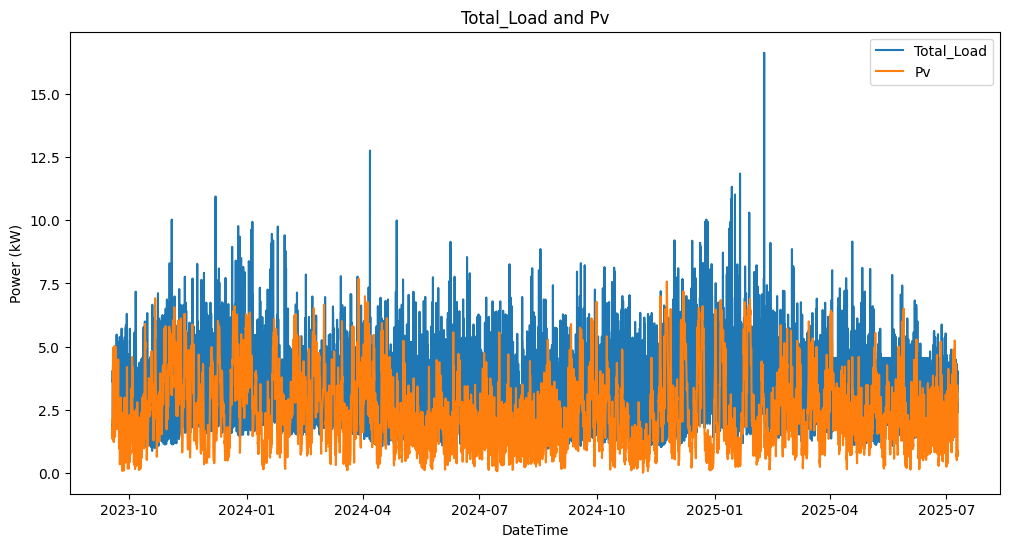

In [ ]:
# Grafico che traccia la potenza totale (Total_Load) e la potenza prodotta (Pv) in funzione del tempo (DateTime)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(Tabella_Batteria['DateTime'], Tabella_Batteria['Total_Load'], label='Total_Load')
plt.plot(Tabella_Batteria['DateTime'], Tabella_Batteria['Pv'], label='Pv')
plt.xlabel('DateTime')        
plt.ylabel('Power (kW)')
plt.title('Total_Load and Pv')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

df = Tabella_Batteria.copy()

# =========================
# PARAMETRI BATTERIA
# =========================
E_max = 80.0        # kWh capacità nominale batteria
P_max = 10.0        # kW potenza massima carica/scarica
eta_ch = 0.95       # efficienza di carica
eta_dis = 0.95      # efficienza di scarica

# limiti realistici di utilizzo batteria
SOC_min = 0.10
SOC_max = 0.90

E_min = SOC_min * E_max
E_max_use = SOC_max * E_max

# stato iniziale batteria
soc = 0.50
energy = soc * E_max

# =========================
# LISTE RISULTATI
# =========================
soc_list = []
energy_list = []
battery_power = []         # >0 scarica, <0 carica
grid_power = []            # >0 import, <0 export
grid_import = []
grid_export = []
pv_to_load = []
pv_to_battery = []
battery_to_load = []
pv_to_grid = []
curtailment = []
surplus_list = []
deficit_list = []
net_load_list = []
charge_power_list = []
discharge_power_list = []
balance_check = []

# =========================
# LOOP PRINCIPALE
# =========================
for _, row in df.iterrows():
    
    pv = float(row["Pv"])
    load = float(row["Total_Load"])
    
    # quota di PV che soddisfa direttamente il carico
    pv_load = min(pv, load)
    
    # surplus o deficit dopo autoconsumo diretto
    surplus = max(pv - pv_load, 0.0)
    deficit = max(load - pv_load, 0.0)
    net_load = load - pv   # utile per controlli
    
    P_ch = 0.0
    P_dis = 0.0
    grid_imp = 0.0
    grid_exp = 0.0
    curt = 0.0
    
    # =====================
    # CASO 1: SURPLUS -> CARICA BATTERIA
    # =====================
    if surplus > 0:
        
        # limite di potenza
        charge_possible = min(P_max, surplus)
        
        # limite di spazio disponibile in batteria
        # se carico P_ch per 1h, l'energia aumenta di eta_ch * P_ch
        space_left = max(E_max_use - energy, 0.0)
        charge_possible = min(charge_possible, space_left / eta_ch if eta_ch > 0 else 0.0)
        
        P_ch = max(charge_possible, 0.0)
        
        # aggiorno energia batteria
        energy += P_ch * eta_ch
        
        # ciò che rimane va in export
        grid_exp = max(surplus - P_ch, 0.0)
        
        # se vuoi distinguere export utile da energia persa, puoi usare curtailment
        # qui per semplicità consideriamo che tutto il surplus residuo venga esportato
        curt = 0.0
    
    # =====================
    # CASO 2: DEFICIT -> SCARICA BATTERIA
    # =====================
    elif deficit > 0:
        
        # limite di potenza
        discharge_possible = min(P_max, deficit)
        
        # limite di energia disponibile sopra SOC_min
        available_energy = max(energy - E_min, 0.0)
        discharge_possible = min(discharge_possible, available_energy * eta_dis)
        
        P_dis = max(discharge_possible, 0.0)
        
        # aggiorno energia batteria
        energy -= P_dis / eta_dis if eta_dis > 0 else 0.0
        
        # il resto del deficit viene importato dalla rete
        grid_imp = max(deficit - P_dis, 0.0)
    
    # sicurezza numerica
    energy = min(max(energy, E_min), E_max_use)
    soc = energy / E_max
    
    # convenzione segni:
    # Battery_Power > 0 scarica
    # Battery_Power < 0 carica
    bat_power = P_dis - P_ch
    
    # convenzione:
    # Grid_Power > 0 import
    # Grid_Power < 0 export
    g_power = grid_imp - grid_exp
    
    # controllo bilancio:
    # PV + Grid_import + Battery_to_Load = Load + PV_to_Battery + Grid_export + Curtailment
    lhs = pv + grid_imp + P_dis
    rhs = load + P_ch + grid_exp + curt
    balance_err = lhs - rhs
    
    # salva risultati
    soc_list.append(soc)
    energy_list.append(energy)
    battery_power.append(bat_power)
    grid_power.append(g_power)
    grid_import.append(grid_imp)
    grid_export.append(grid_exp)
    pv_to_load.append(pv_load)
    pv_to_battery.append(P_ch)
    battery_to_load.append(P_dis)
    pv_to_grid.append(grid_exp)
    curtailment.append(curt)
    surplus_list.append(surplus)
    deficit_list.append(deficit)
    net_load_list.append(net_load)
    charge_power_list.append(P_ch)
    discharge_power_list.append(P_dis)
    balance_check.append(balance_err)

# =========================
# AGGIUNTA COLONNE
# =========================
df["PV_to_Load"] = pv_to_load
df["PV_to_Battery"] = pv_to_battery
df["Battery_to_Load"] = battery_to_load

df["Charge_Power"] = charge_power_list
df["Discharge_Power"] = discharge_power_list

df["Battery_Power"] = battery_power
df["Battery_Energy_kWh"] = energy_list
df["SOC"] = soc_list

df["Grid_Import"] = grid_import
df["Grid_Export"] = grid_export
df["Grid_Power"] = grid_power

df["PV_to_Grid"] = pv_to_grid
df["Curtailment"] = curtailment

df["Surplus"] = surplus_list
df["Deficit"] = deficit_list
df["Net_Load"] = net_load_list

df["Balance_Error"] = balance_check

# =========================
# CONTROLLI FINALI
# =========================
print("Controllo SOC:")
print(df["SOC"].describe())

print("\nControllo energia batteria:")
print(df["Battery_Energy_kWh"].describe())

print("\nControllo Grid_Power:")
print(df["Grid_Power"].describe())

print("\nErrore massimo di bilancio energetico:")
print(df["Balance_Error"].abs().max())

Controllo SOC:
count    15842.000000
mean         0.252400
std          0.253256
min          0.100000
25%          0.100000
50%          0.100000
75%          0.309755
max          0.900000
Name: SOC, dtype: float64

Controllo energia batteria:
count    15842.000000
mean        20.192020
std         20.260505
min          8.000000
25%          8.000000
50%          8.000000
75%         24.780430
max         72.000000
Name: Battery_Energy_kWh, dtype: float64

Controllo Grid_Power:
count    15842.000000
mean         0.883070
std          1.497216
min         -5.206223
25%          0.000000
50%          0.096989
75%          1.619636
max         14.765357
Name: Grid_Power, dtype: float64

Errore massimo di bilancio energetico:
1.7763568394002505e-15


In [ ]:
import pandas as pd
import numpy as np

# 1) Copia e sistema tipi
check_df = df.copy()
check_df["DateTime"] = pd.to_datetime(check_df["DateTime"], errors="coerce")

# 2) Differenza tra produzione e carico
check_df["Surplus"] = check_df["Pv"] - check_df["Total_Load"]

# 3) Quante ore hanno surplus?
n_total = len(check_df)
n_surplus = (check_df["Surplus"] > 0).sum()
pct_surplus = 100 * n_surplus / n_total

print("===== CONTROLLO SURPLUS PV =====")
print("Numero totale ore:", n_total)
print("Ore con Pv > Total_Load:", n_surplus)
print("Percentuale ore con surplus:", round(pct_surplus, 2), "%")

# 4) Statistiche base di Pv, Load e Surplus
print("\n===== STATISTICHE GENERALI =====")
print(check_df[["Pv", "Total_Load", "Surplus"]].describe())

# 5) Rapporto PV / Load quando il load è positivo
check_df["Pv_Load_Ratio"] = np.where(
    check_df["Total_Load"] > 0,
    check_df["Pv"] / check_df["Total_Load"],
    np.nan
)

print("\n===== RAPPORTO PV / LOAD =====")
print(check_df["Pv_Load_Ratio"].describe())

# 6) Statistiche solo nelle ore con surplus
surplus_df = check_df[check_df["Surplus"] > 0].copy()

print("\n===== SOLO ORE CON SURPLUS =====")
if len(surplus_df) > 0:
    print("Numero ore con surplus:", len(surplus_df))
    print("Surplus medio (kW):", surplus_df["Surplus"].mean())
    print("Surplus massimo (kW):", surplus_df["Surplus"].max())
    print(surplus_df[["Pv", "Total_Load", "Surplus"]].describe())
else:
    print("Nessuna ora con surplus.")

# 7) Quanti giorni hanno almeno un'ora di surplus?
check_df["Date"] = check_df["DateTime"].dt.date
days_with_surplus = check_df.groupby("Date")["Surplus"].apply(lambda x: (x > 0).any())

print("\n===== SURPLUS A LIVELLO GIORNALIERO =====")
print("Numero giorni totali:", days_with_surplus.shape[0])
print("Numero giorni con almeno un'ora di surplus:", days_with_surplus.sum())
print("Percentuale giorni con almeno un'ora di surplus:", round(100 * days_with_surplus.mean(), 2), "%")

# 8) Quante ore consecutive di surplus ci sono?
surplus_mask = check_df["Surplus"] > 0
groups = (surplus_mask != surplus_mask.shift()).cumsum()
surplus_runs = surplus_mask.groupby(groups).sum()
surplus_runs = surplus_runs[surplus_runs > 0]

print("\n===== RUN CONSECUTIVI DI SURPLUS =====")
if len(surplus_runs) > 0:
    print("Numero di sequenze di surplus:", len(surplus_runs))
    print("Lunghezza media sequenza (ore):", surplus_runs.mean())
    print("Lunghezza massima sequenza (ore):", surplus_runs.max())
    print(surplus_runs.describe())
else:
    print("Nessuna sequenza di surplus.")

# 9) Medie mensili utili per capire stagionalità
check_df["Month"] = check_df["DateTime"].dt.to_period("M")

monthly_summary = check_df.groupby("Month")[["Pv", "Total_Load", "Surplus"]].mean()

print("\n===== MEDIE MENSILI =====")
print(monthly_summary)

# 10) Top 10 ore con massimo surplus
print("\n===== TOP 10 ORE CON MASSIMO SURPLUS =====")
print(
    check_df.sort_values("Surplus", ascending=False)[
        ["DateTime", "Pv", "Total_Load", "Surplus", "Pv_Load_Ratio"]
    ].head(10)
)

# 11) Top 10 ore con massimo deficit
print("\n===== TOP 10 ORE CON MASSIMO DEFICIT =====")
print(
    check_df.sort_values("Surplus", ascending=True)[
        ["DateTime", "Pv", "Total_Load", "Surplus", "Pv_Load_Ratio"]
    ].head(10)
)

===== CONTROLLO SURPLUS PV =====
Numero totale ore: 15842
Ore con Pv > Total_Load: 4784
Percentuale ore con surplus: 30.2 %

===== STATISTICHE GENERALI =====
                 Pv    Total_Load       Surplus
count  15842.000000  15842.000000  15842.000000
mean       2.333387      3.190653     -0.857267
std        1.463862      1.396705      1.852271
min        0.019168      0.883117    -14.765357
25%        1.175930      2.103534     -1.929437
50%        2.067483      2.973534     -0.867576
75%        3.178887      3.970946      0.271325
max        7.688286     16.619681      5.680059

===== RAPPORTO PV / LOAD =====
count    15842.000000
mean         0.828234
std          0.601732
min          0.006202
25%          0.397169
50%          0.678326
75%          1.111174
max          5.748272
Name: Pv_Load_Ratio, dtype: float64

===== SOLO ORE CON SURPLUS =====
Numero ore con surplus: 4784
Surplus medio (kW): 1.2141877020999121
Surplus massimo (kW): 5.680059319508034
                Pv   Tot

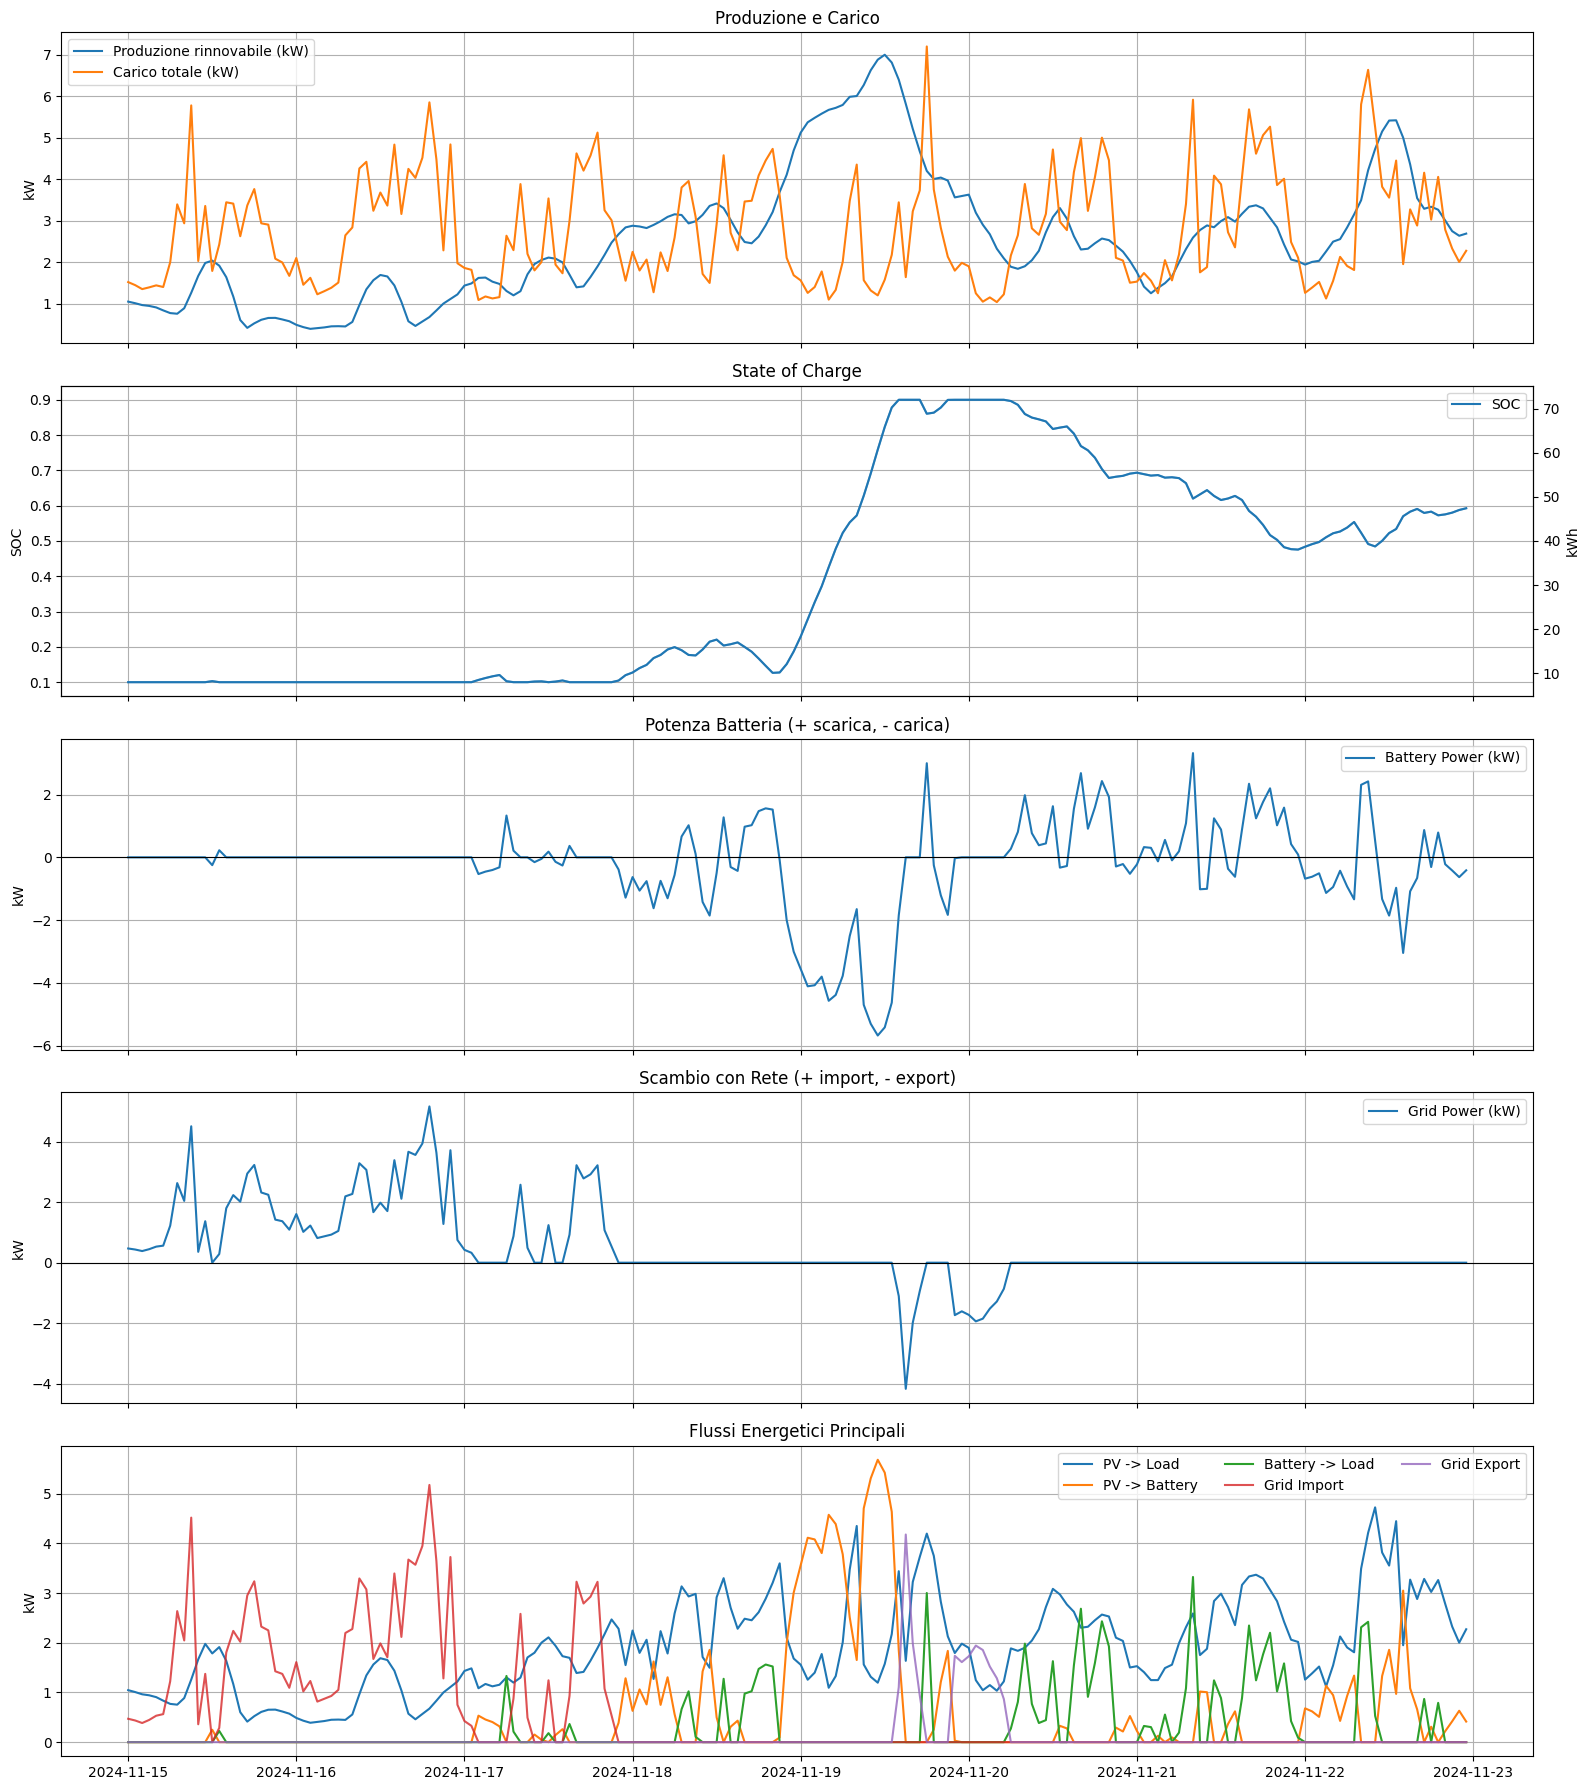

SOC minimo: 0.1
SOC massimo: 0.9
Energia batteria minima (kWh): 8.0
Energia batteria massima (kWh): 72.0
Import totale da rete (kWh circa): 111.65333319169247
Export totale verso rete (kWh circa): 20.751237469022477
Massimo errore di bilancio: 8.881784197001252e-16


In [ ]:
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["DateTime"] = pd.to_datetime(plot_df["DateTime"], errors="coerce")
plot_df = plot_df.sort_values("DateTime").set_index("DateTime")

# opzionale: scegli una finestra temporale per vedere meglio i dettagli
# esempio: una settimana
start = "2024-11-15"
end   = "2024-11-22"
plot_df = plot_df.loc[start:end]

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

# 1) Generazione e carico
axes[0].plot(plot_df.index, plot_df["Pv"], label="Produzione rinnovabile (kW)")
axes[0].plot(plot_df.index, plot_df["Total_Load"], label="Carico totale (kW)")
axes[0].set_title("Produzione e Carico")
axes[0].set_ylabel("kW")
axes[0].legend()
axes[0].grid(True)

# 2) SOC ed energia batteria
axes[1].plot(plot_df.index, plot_df["SOC"], label="SOC")
axes[1].set_title("State of Charge")
axes[1].set_ylabel("SOC")
axes[1].legend()
axes[1].grid(True)

# asse secondario per energia batteria
ax2 = axes[1].twinx()
ax2.plot(plot_df.index, plot_df["Battery_Energy_kWh"], label="Energia batteria (kWh)", alpha=0.5)
ax2.set_ylabel("kWh")

# 3) Potenza batteria
axes[2].plot(plot_df.index, plot_df["Battery_Power"], label="Battery Power (kW)")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Potenza Batteria (+ scarica, - carica)")
axes[2].set_ylabel("kW")
axes[2].legend()
axes[2].grid(True)

# 4) Scambio con rete
axes[3].plot(plot_df.index, plot_df["Grid_Power"], label="Grid Power (kW)")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_title("Scambio con Rete (+ import, - export)")
axes[3].set_ylabel("kW")
axes[3].legend()
axes[3].grid(True)

# 5) Flussi principali
axes[4].plot(plot_df.index, plot_df["PV_to_Load"], label="PV -> Load")
axes[4].plot(plot_df.index, plot_df["PV_to_Battery"], label="PV -> Battery")
axes[4].plot(plot_df.index, plot_df["Battery_to_Load"], label="Battery -> Load")
axes[4].plot(plot_df.index, plot_df["Grid_Import"], label="Grid Import", alpha=0.8)
axes[4].plot(plot_df.index, plot_df["Grid_Export"], label="Grid Export", alpha=0.8)
axes[4].set_title("Flussi Energetici Principali")
axes[4].set_ylabel("kW")
axes[4].legend(ncol=3)
axes[4].grid(True)

plt.xlabel("Tempo")
plt.tight_layout()
plt.show()

# controlli numerici rapidi
print("SOC minimo:", plot_df["SOC"].min())
print("SOC massimo:", plot_df["SOC"].max())
print("Energia batteria minima (kWh):", plot_df["Battery_Energy_kWh"].min())
print("Energia batteria massima (kWh):", plot_df["Battery_Energy_kWh"].max())
print("Import totale da rete (kWh circa):", plot_df["Grid_Import"].sum())
print("Export totale verso rete (kWh circa):", plot_df["Grid_Export"].sum())
print("Massimo errore di bilancio:", plot_df["Balance_Error"].abs().max())

In [ ]:
import pandas as pd
import numpy as np

check = df.copy()

# Assicuriamoci che il tempo sia datetime
check["DateTime"] = pd.to_datetime(check["DateTime"], errors="coerce")

# =========================
# ENERGIE TOTALI (kWh circa, dato passo orario)
# =========================
E_load = check["Total_Load"].sum()
E_pv = check["Pv"].sum()

E_pv_to_load = check["PV_to_Load"].sum()
E_pv_to_battery = check["PV_to_Battery"].sum()
E_battery_to_load = check["Battery_to_Load"].sum()

E_grid_import = check["Grid_Import"].sum()
E_grid_export = check["Grid_Export"].sum()

E_curtailment = check["Curtailment"].sum() if "Curtailment" in check.columns else 0.0

# =========================
# INDICATORI PRINCIPALI
# =========================

# Quota del carico coperta direttamente da rinnovabili
direct_renewable_share = E_pv_to_load / E_load if E_load > 0 else np.nan

# Quota del carico coperta dalla batteria
battery_share = E_battery_to_load / E_load if E_load > 0 else np.nan

# Quota del carico coperta dalla rete
grid_share = E_grid_import / E_load if E_load > 0 else np.nan

# Autosufficienza: quanta parte del carico è soddisfatta localmente
self_sufficiency = (E_pv_to_load + E_battery_to_load) / E_load if E_load > 0 else np.nan

# Autoconsumo del rinnovabile:
# quanta parte della generazione rinnovabile viene usata localmente
self_consumption = (E_pv_to_load + E_pv_to_battery) / E_pv if E_pv > 0 else np.nan

# Export ratio: quota della produzione rinnovabile esportata
export_ratio = E_grid_export / E_pv if E_pv > 0 else np.nan

# Import dependency: quanto il sistema dipende dalla rete
import_dependency = E_grid_import / E_load if E_load > 0 else np.nan

# Round-trip batteria "apparente"
battery_roundtrip = E_battery_to_load / E_pv_to_battery if E_pv_to_battery > 0 else np.nan

# =========================
# CONTROLLI DI COERENZA
# =========================

# Bilancio lato carico:
# carico ≈ PV->Load + Battery->Load + Grid Import
load_balance_error = E_load - (E_pv_to_load + E_battery_to_load + E_grid_import)

# Bilancio lato PV:
# PV ≈ PV->Load + PV->Battery + Grid Export + Curtailment
pv_balance_error = E_pv - (E_pv_to_load + E_pv_to_battery + E_grid_export + E_curtailment)

# Escursione SOC
soc_min = check["SOC"].min()
soc_max = check["SOC"].max()

# =========================
# RISULTATI
# =========================
print("===== ENERGIE TOTALI (kWh circa) =====")
print(f"Energia totale carico                 : {E_load:.3f}")
print(f"Energia totale rinnovabile            : {E_pv:.3f}")
print(f"PV -> Load                            : {E_pv_to_load:.3f}")
print(f"PV -> Battery                         : {E_pv_to_battery:.3f}")
print(f"Battery -> Load                       : {E_battery_to_load:.3f}")
print(f"Grid Import                           : {E_grid_import:.3f}")
print(f"Grid Export                           : {E_grid_export:.3f}")
print(f"Curtailment                           : {E_curtailment:.3f}")

print("\n===== INDICATORI DI PERFORMANCE =====")
print(f"Quota carico coperta direttamente da rinnovabili : {100*direct_renewable_share:.2f}%")
print(f"Quota carico coperta dalla batteria               : {100*battery_share:.2f}%")
print(f"Quota carico coperta dalla rete                   : {100*grid_share:.2f}%")
print(f"Autosufficienza del sistema                       : {100*self_sufficiency:.2f}%")
print(f"Autoconsumo del rinnovabile                       : {100*self_consumption:.2f}%")
print(f"Quota produzione esportata                        : {100*export_ratio:.2f}%")
print(f"Dipendenza dalla rete                             : {100*import_dependency:.2f}%")
print(f"Round-trip apparente batteria                     : {100*battery_roundtrip:.2f}%")

print("\n===== CONTROLLI DI COERENZA =====")
print(f"Errore bilancio lato carico : {load_balance_error:.10f}")
print(f"Errore bilancio lato PV     : {pv_balance_error:.10f}")
print(f"SOC minimo                  : {soc_min:.3f}")
print(f"SOC massimo                 : {soc_max:.3f}")

# =========================
# STATISTICHE GIORNALIERE UTILI
# =========================
daily = check.set_index("DateTime").resample("D").sum(numeric_only=True)

print("\n===== STATISTICHE GIORNALIERE =====")
print("Carico giornaliero (kWh):")
print(daily["Total_Load"].describe())

print("\nProduzione giornaliera rinnovabile (kWh):")
print(daily["Pv"].describe())

print("\nImport giornaliero da rete (kWh):")
print(daily["Grid_Import"].describe())

print("\nExport giornaliero verso rete (kWh):")
print(daily["Grid_Export"].describe())

# =========================
# GIORNI PIÙ INTERESSANTI
# =========================
print("\n===== TOP 10 GIORNI PER IMPORT DA RETE =====")
print(daily["Grid_Import"].sort_values(ascending=False).head(10))

print("\n===== TOP 10 GIORNI PER EXPORT VERSO RETE =====")
print(daily["Grid_Export"].sort_values(ascending=False).head(10))

print("\n===== TOP 10 GIORNI PER PRODUZIONE RINNOVABILE =====")
print(daily["Pv"].sort_values(ascending=False).head(10))

print("\n===== TOP 10 GIORNI PER CARICO =====")
print(daily["Total_Load"].sort_values(ascending=False).head(10))

===== ENERGIE TOTALI (kWh circa) =====
Energia totale carico                 : 50546.332
Energia totale rinnovabile            : 36965.514
PV -> Load                            : 31156.840
PV -> Battery                         : 4504.401
Battery -> Load                       : 4095.622
Grid Import                           : 15293.870
Grid Export                           : 1304.273
Curtailment                           : 0.000

===== INDICATORI DI PERFORMANCE =====
Quota carico coperta direttamente da rinnovabili : 61.64%
Quota carico coperta dalla batteria               : 8.10%
Quota carico coperta dalla rete                   : 30.26%
Autosufficienza del sistema                       : 69.74%
Autoconsumo del rinnovabile                       : 96.47%
Quota produzione esportata                        : 3.53%
Dipendenza dalla rete                             : 30.26%
Round-trip apparente batteria                     : 90.92%

===== CONTROLLI DI COERENZA =====
Errore bilancio lato cari

In [ ]:
import pandas as pd
import numpy as np

check = df.copy()

# parametri batteria (devono essere gli stessi usati nella simulazione)
E_max = 80
eta = 0.95

print("\n==============================")
print("CHECK 1: BILANCIO ENERGETICO MICROGRID")
print("==============================")

# lato sinistro e destro dell'equazione
check["LHS_energy"] = (
    check["Pv"]
    + check["Grid_Import"]
    + check["Battery_to_Load"]
)

check["RHS_energy"] = (
    check["Total_Load"]
    + check["PV_to_Battery"]
    + check["Grid_Export"]
)

check["Energy_Balance_Error"] = check["LHS_energy"] - check["RHS_energy"]

print(check["Energy_Balance_Error"].describe())

print("\nErrore assoluto massimo:")
print(check["Energy_Balance_Error"].abs().max())

print("\nErrore assoluto medio:")
print(check["Energy_Balance_Error"].abs().mean())


print("\n==============================")
print("CHECK 2: DINAMICA DELLA BATTERIA")
print("==============================")

# energia batteria prevista dalla fisica
energy = check["Battery_Energy_kWh"].values

# calcolo energia prevista usando l'equazione fisica
energy_pred = np.zeros(len(check))
energy_pred[0] = energy[0]

for t in range(1, len(check)):

    charge = check["PV_to_Battery"].iloc[t-1]
    discharge = check["Battery_to_Load"].iloc[t-1]

    energy_pred[t] = (
        energy_pred[t-1]
        + charge * eta
        - discharge / eta
    )

check["Battery_Energy_Predicted"] = energy_pred

check["Battery_Dynamics_Error"] = (
    check["Battery_Energy_kWh"] - check["Battery_Energy_Predicted"]
)

print(check["Battery_Dynamics_Error"].describe())

print("\nErrore assoluto massimo:")
print(check["Battery_Dynamics_Error"].abs().max())

print("\nErrore assoluto medio:")
print(check["Battery_Dynamics_Error"].abs().mean())


print("\n==============================")
print("CHECK 3: LIMITI FISICI BATTERIA")
print("==============================")

print("SOC minimo:", check["SOC"].min())
print("SOC massimo:", check["SOC"].max())

print("Energia minima batteria:", check["Battery_Energy_kWh"].min())
print("Energia massima batteria:", check["Battery_Energy_kWh"].max())


print("\n==============================")
print("CHECK 4: COERENZA SOC")
print("==============================")

soc_from_energy = check["Battery_Energy_kWh"] / E_max

soc_error = check["SOC"] - soc_from_energy

print("Errore SOC medio:", soc_error.abs().mean())
print("Errore SOC massimo:", soc_error.abs().max())


CHECK 1: BILANCIO ENERGETICO MICROGRID
count    1.584200e+04
mean     8.970367e-19
std      9.601133e-17
min     -1.776357e-15
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.776357e-15
Name: Energy_Balance_Error, dtype: float64

Errore assoluto massimo:
1.7763568394002505e-15

Errore assoluto medio:
1.440865129800102e-17

CHECK 2: DINAMICA DELLA BATTERIA
count    15842.000000
mean        -0.037302
std          1.051250
min         -9.594094
25%         -0.035282
50%         -0.035282
75%          0.033673
max          5.360774
Name: Battery_Dynamics_Error, dtype: float64

Errore assoluto massimo:
9.594094349979088

Errore assoluto medio:
0.5590759566218454

CHECK 3: LIMITI FISICI BATTERIA
SOC minimo: 0.1
SOC massimo: 0.9
Energia minima batteria: 8.0
Energia massima batteria: 72.0

CHECK 4: COERENZA SOC
Errore SOC medio: 0.0
Errore SOC massimo: 0.0

RISULTATO
Se tutti gli errori sono ~ 1e-10 o meno:
✔ dataset fisicamente coerente
✔ pronto per PINN


In [ ]:
df.columns

Index(['DateTime', 'House1', 'House2', 'House3', 'House4', 'House5', 'House11',
       'Total_Load', 'Day_of_Year', 'Day_Name', 'Month_Name', 'Season', 'Year',
       'Pv', 'PV_to_Load', 'PV_to_Battery', 'Battery_to_Load', 'Charge_Power',
       'Discharge_Power', 'Battery_Power', 'Battery_Energy_kWh', 'SOC',
       'Grid_Import', 'Grid_Export', 'Grid_Power', 'PV_to_Grid', 'Curtailment',
       'Surplus', 'Deficit', 'Net_Load', 'Balance_Error'],
      dtype='str')

In [ ]:
# Rinomino il dataset df come pinn_df e lo salvo come file csv
pinn_df = df.copy()
pinn_df.to_csv(r"C:\Users\vinsc\Documents\Progetti\pinn_df.csv", index=False)
pinn_df.head()

,DateTime,House1,House2,House3,House4,House5,House11,Total_Load,Day_of_Year,Day_Name,...,SOC,Grid_Import,Grid_Export,Grid_Power,PV_to_Grid,Curtailment,Surplus,Deficit,Net_Load,Balance_Error
0,2023-09-18 00:00:00,0.353926,0.084078,0.303328,0.252427,0.386085,0.209238,1.769925,261,Monday,...,0.500441,0.0,0.0,0.0,0.0,0.0,0.037139,0.000000,-0.037139,0.0
1,2023-09-18 01:00:00,0.526320,0.057124,0.283109,0.226029,0.441071,0.176473,1.904744,261,Monday,...,0.493281,0.0,0.0,0.0,0.0,0.0,0.000000,0.544158,0.544158,0.0
2,2023-09-18 02:00:00,0.536236,0.081743,0.280368,0.218727,0.484487,0.141122,1.941006,261,Monday,...,0.490636,0.0,0.0,0.0,0.0,0.0,0.000000,0.201029,0.201029,0.0
3,2023-09-18 03:00:00,0.539307,0.085029,0.270917,0.206596,0.433297,0.121543,1.845225,261,Monday,...,0.492616,0.0,0.0,0.0,0.0,0.0,0.166737,0.000000,-0.166737,0.0
4,2023-09-18 04:00:00,0.553143,0.058800,0.265627,0.209230,0.420699,0.135342,1.829802,261,Monday,...,0.496004,0.0,0.0,0.0,0.0,0.0,0.285270,0.000000,-0.285270,0.0
